# Exercise: Recommendation as a Contextual Bandit
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Formulate recommendation as a sequential decision problem
- Implement an ε-greedy contextual bandit that **learns** from feedback
- Measure the cost of exploration against an oracle and a random baseline
- Reason about what changes when the feedback comes from real users

## What is real here and what is not

> The click behaviour in this exercise comes from a **simulator we wrote**, not from a company's
> logs. Real recommender data is proprietary and is not shipped with this course, and there is
> no honest way around that. What *is* real is the **problem shape**: an agent that must choose
> an item, sees only the feedback for the item it chose, and never learns what would have
> happened with the others. That "you only see what you picked" structure is the whole
> difficulty of recommendation, and it is what you are practising here.
>
> Do not read the learned click rates as facts about any product.

**Task**: build an agent that learns which item to show each user segment, from feedback alone.

---

## Task 1: Recommendation Environment (30 points)

Complete/extend the environment below:
1. User segments (the **context**, i.e. the state)
2. Items that can be recommended (the **actions**)
3. A reward: `1` if the user clicked, `0` if not — sampled, never revealed in advance

## Exercise Brief

This exercise checks whether students can apply RL thinking to an application scenario, not only to a textbook algorithm.

They should identify states, actions, rewards, risks, and trade-offs in a realistic decision problem.

Why this matters: Unit 5 is about transfer of understanding from theory to applications.

This exercise verifies that students can reason about that transfer clearly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

This exercise asks you to formulate an application problem, define the RL pieces,
and reason about the trade-offs rather than jumping straight to a large training system.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Recommendation policy: what to show the user.
- Feedback signal: clicks or other user response.
- Long-term engagement: more than one-step reward.
- Preference uncertainty: not knowing the user fully yet.

### Quick Check
- Why can recommendation be an RL problem?
- What goes wrong if we optimize only immediate clicks?
- Where are states, actions, and rewards here?

### Common Mistakes
- Reducing recommendation to one-step prediction.
- Using the wrong reward proxy.
- Ignoring exploration of user preferences.


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# WHAT: a contextual-bandit simulator for recommendation, plus a quick sanity check.
# WHY: the agent must not be able to read the click probabilities - it may only observe the
#      0/1 outcome of the item it actually showed. Hiding CLICK_RATES inside the environment is
#      what makes this a learning problem instead of a lookup.

import numpy as np


class RecommendationEnv:
    """One-step contextual bandit: a user segment arrives, the agent shows one item, a click happens or not.

    The click probabilities live inside the environment. The agent never sees them - it only
    sees the 0/1 outcome for the single item it chose. That is "bandit feedback".
    """

    SEGMENTS = ["news reader", "sports fan", "cooking enthusiast"]
    ITEMS = ["breaking-news article", "match report", "recipe video", "general digest"]

    # Hidden ground truth: P(click | segment, item). Written by us, unknown to the agent.
    CLICK_RATES = np.array([
        [0.42, 0.10, 0.06, 0.22],    # news reader
        [0.12, 0.48, 0.05, 0.20],    # sports fan
        [0.08, 0.06, 0.45, 0.19],    # cooking enthusiast
    ])

    def __init__(self, seed=0):
        # One seeded generator: which user arrives, and whether they click, are BOTH random.
        # That randomness is the environment, and it is exactly what the agent must average out.
        self.rng = np.random.default_rng(seed)
        self.n_segments = len(self.SEGMENTS)
        self.n_items = len(self.ITEMS)
        self.current_segment = 0

    def reset(self):
        """A new user session begins: sample which segment showed up. Returns the context."""
        self.current_segment = int(self.rng.integers(self.n_segments))
        return self.current_segment

    def step(self, action):
        """Show item `action` to the current user. Returns (context, reward, done, info)."""
        probability = self.CLICK_RATES[self.current_segment, action]
        reward = float(self.rng.random() < probability)   # 1 = clicked, 0 = ignored
        info = {"segment": self.SEGMENTS[self.current_segment], "item": self.ITEMS[action]}
        return self.current_segment, reward, True, info


env = RecommendationEnv(seed=0)
segment = env.reset()
_, reward, _, info = env.step(1)
print("Segments :", env.SEGMENTS)
print("Items    :", env.ITEMS)
print(f"\nSample session: a '{info['segment']}' arrived, we showed '{info['item']}', "
      f"click = {int(reward)}")
print("\nNotice what the agent did NOT learn from that session: whether the other three items")
print("would have been clicked. One session gives one bit of evidence about one item.")


Segments : ['news reader', 'sports fan', 'cooking enthusiast']
Items    : ['breaking-news article', 'match report', 'recipe video', 'general digest']

Sample session: a 'cooking enthusiast' arrived, we showed 'match report', click = 0

Notice what the agent did NOT learn from that session: whether the other three items
would have been clicked. One session gives one bit of evidence about one item.


## Task 2: The Agent (35 points)

Implement an agent that **learns** the best item per segment from feedback alone.

1. An estimate of click rate per `(segment, item)` pair, updated from observed rewards
2. An action-selection rule that explores as well as exploits (ε-greedy is enough)
3. An evaluation that compares your agent against two reference points:
   - a **random** policy (no learning at all)
   - the **oracle** that always shows the truly best item for each segment

The oracle is only available to us because we wrote the simulator. In a real deployment nobody
can compute it — which is exactly why the gap between your agent and the oracle is the number
worth watching.

You do **not** need a deep-learning stack.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


In [2]:
# WHAT: an epsilon-greedy contextual bandit that learns click rates from feedback, scored
#       against a random policy and against the (normally unknowable) oracle.
# WHY: the point of the exercise is that exploration has a price and learning pays it back.
#      Both claims are measured below rather than asserted.

def run_epsilon_greedy(env, n_sessions=20_000, epsilon=0.1, seed=1):
    """Learn P(click | segment, item) by trying items and counting what came back."""
    rng = np.random.default_rng(seed)
    # Running estimates the agent builds itself - it starts knowing nothing.
    clicks = np.zeros((env.n_segments, env.n_items))
    shows = np.zeros((env.n_segments, env.n_items))
    reward_log = []
    for _ in range(n_sessions):
        segment = env.reset()
        if rng.random() < epsilon:
            item = int(rng.integers(env.n_items))          # explore: learn about an item
        else:
            estimates = clicks[segment] / np.maximum(shows[segment], 1)
            item = int(np.argmax(estimates))               # exploit: use what we believe
        _, reward, _, _ = env.step(item)
        shows[segment, item] += 1
        clicks[segment, item] += reward
        reward_log.append(reward)
    estimated_rates = clicks / np.maximum(shows, 1)
    return estimated_rates, shows, np.array(reward_log)


def run_random(env, n_sessions=20_000, seed=2):
    """No learning at all: pick an item uniformly every time. The floor to beat."""
    rng = np.random.default_rng(seed)
    rewards = []
    for _ in range(n_sessions):
        env.reset()
        _, reward, _, _ = env.step(int(rng.integers(env.n_items)))
        rewards.append(reward)
    return np.array(rewards)


N_SESSIONS = 20_000
learner_env = RecommendationEnv(seed=10)
estimated_rates, shows, learner_rewards = run_epsilon_greedy(learner_env, N_SESSIONS)
random_rewards = run_random(RecommendationEnv(seed=10), N_SESSIONS)

# The oracle click rate: average of the best true rate per segment (segments arrive equally often).
true_rates = RecommendationEnv.CLICK_RATES
oracle_rate = float(true_rates.max(axis=1).mean())

print(f"Click-through rate over {N_SESSIONS:,} sessions")
print("=" * 58)
print(f"  random policy (no learning) : {random_rewards.mean() * 100:5.2f}%")
print(f"  epsilon-greedy learner      : {learner_rewards.mean() * 100:5.2f}%")
print(f"  oracle (knows the answer)   : {oracle_rate * 100:5.2f}%")
gap = oracle_rate - learner_rewards.mean()
print(f"\n  Gap to the oracle: {gap * 100:.2f} percentage points. That gap is mostly the price of")
print("  exploration - 10% of sessions were deliberately spent on items we did not expect to win.")

print("\nWhat the agent learned vs the truth it never saw:")
print(f"  {'segment':<20}{'agent picks':<26}{'truly best':<26}")
for s, name in enumerate(RecommendationEnv.SEGMENTS):
    learned_best = RecommendationEnv.ITEMS[int(np.argmax(estimated_rates[s]))]
    actual_best = RecommendationEnv.ITEMS[int(np.argmax(true_rates[s]))]
    mark = "" if learned_best == actual_best else "   <-- MISMATCH"
    print(f"  {name:<20}{learned_best:<26}{actual_best:<26}{mark}")

print("\nEstimated click rate vs true click rate (agent estimate | truth):")
header = "  " + " " * 20 + "".join(f"{item[:13]:>15}" for item in RecommendationEnv.ITEMS)
print(header)
for s, name in enumerate(RecommendationEnv.SEGMENTS):
    row = "".join(f"{estimated_rates[s, i]:>7.3f}|{true_rates[s, i]:<7.3f}"
                  for i in range(len(RecommendationEnv.ITEMS)))
    print(f"  {name:<20}{row}")

print("\nLook at how often each item was shown - exploitation concentrates the evidence:")
for s, name in enumerate(RecommendationEnv.SEGMENTS):
    counts = "  ".join(f"{RecommendationEnv.ITEMS[i][:13]}={int(shows[s, i])}"
                       for i in range(len(RecommendationEnv.ITEMS)))
    print(f"  {name:<20}{counts}")
# Measure the point instead of asserting it: how accurate is the estimate for the item the
# agent kept showing, versus the items it mostly abandoned?
errors = np.abs(estimated_rates - true_rates)
exploited = np.zeros(env.n_segments, dtype=bool)
exploited_error, abandoned_error, min_shows = [], [], []
for s in range(len(RecommendationEnv.SEGMENTS)):
    favourite = int(np.argmax(shows[s]))
    exploited_error.append(errors[s, favourite])
    others = [i for i in range(len(RecommendationEnv.ITEMS)) if i != favourite]
    abandoned_error.append(errors[s, others].mean())
    min_shows.append(int(shows[s].min()))

print(f"\nEstimation error, averaged over the three segments:")
print(f"  the item the agent kept showing : {np.mean(exploited_error):.4f} "
      f"(seen thousands of times)")
print(f"  the items it mostly abandoned   : {np.mean(abandoned_error):.4f} "
      f"(as few as {min(min_shows)} times)")
print("\nWith epsilon = 0.1 the abandoned items still get sampled often enough here to stay")
print("roughly right. Set epsilon to 0 and that stops being true: an agent that never tries")
print("an item never corrects its belief about it, and can stay confidently wrong forever.")
print("Try it - change epsilon to 0.0 above and re-run this cell.")


Click-through rate over 20,000 sessions
  random policy (no learning) : 20.14%
  epsilon-greedy learner      : 41.82%
  oracle (knows the answer)   : 45.00%

  Gap to the oracle: 3.18 percentage points. That gap is mostly the price of
  exploration - 10% of sessions were deliberately spent on items we did not expect to win.

What the agent learned vs the truth it never saw:
  segment             agent picks               truly best                
  news reader         breaking-news article     breaking-news article     
  sports fan          match report              match report              
  cooking enthusiast  recipe video              recipe video              

Estimated click rate vs true click rate (agent estimate | truth):
                        breaking-news   match report   recipe video  general diges
  news reader           0.416|0.420    0.097|0.100    0.062|0.060    0.200|0.220  
  sports fan            0.107|0.120    0.479|0.480    0.053|0.050    0.219|0.200  
  cooki

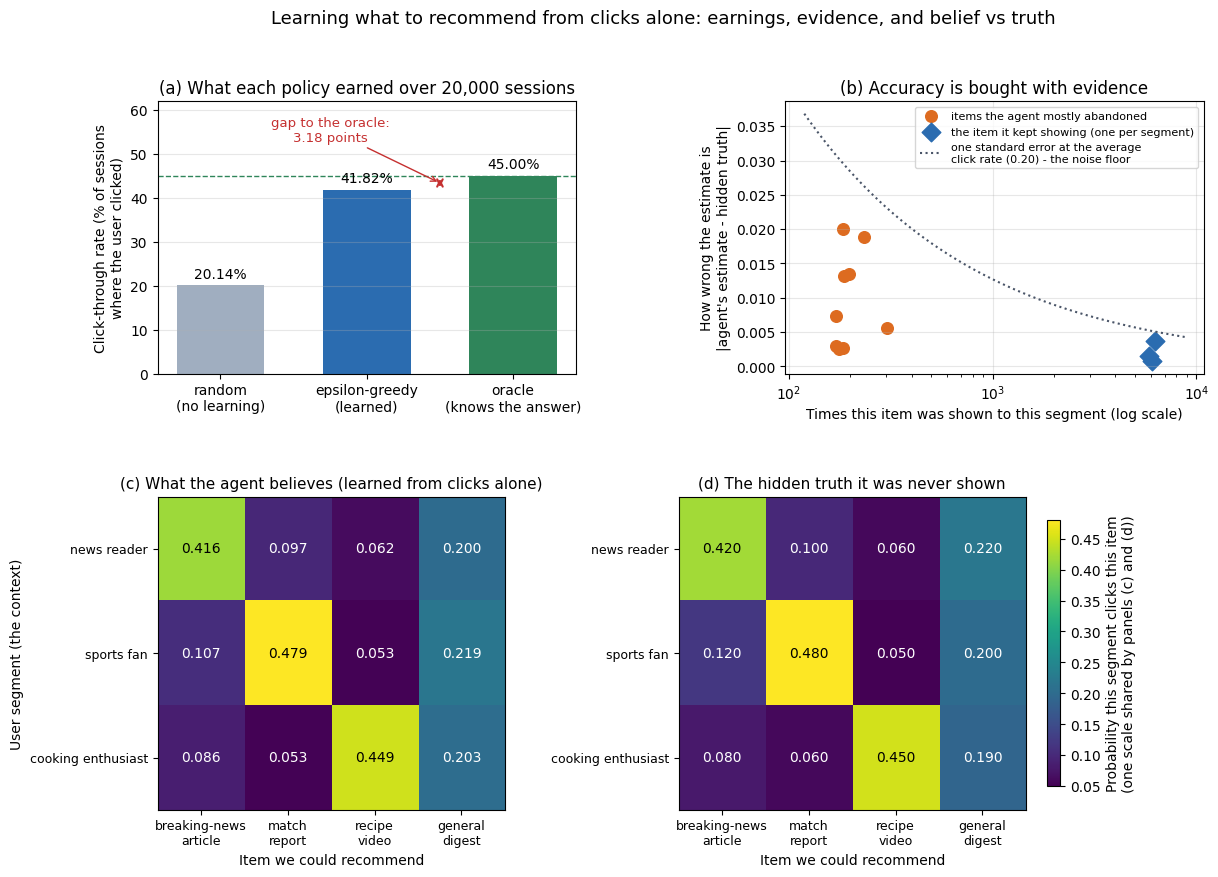

Largest disagreement between belief and truth: 0.020 click-rate points
Colour scale shared by both grids: 0.050 to 0.480


In [3]:
# One figure for the whole exercise: what the agent earned, what it believed, what was true,
# and what its beliefs cost in evidence. Every number below was printed above - nothing is recomputed.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Short two-line item names so the axis ticks stay readable.
item_labels = ["breaking-news\narticle", "match\nreport", "recipe\nvideo", "general\ndigest"]
segment_labels = RecommendationEnv.SEGMENTS

fig = plt.figure(figsize=(13.5, 9.2))
grid = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], hspace=0.42, wspace=0.50)
ax_policy = fig.add_subplot(grid[0, 0])
ax_error = fig.add_subplot(grid[0, 1])
ax_est = fig.add_subplot(grid[1, 0])
ax_true = fig.add_subplot(grid[1, 1])

# ---------- (a) three policies, side by side. Policies are categories, so bars. ----------
policy_names = ["random\n(no learning)", "epsilon-greedy\n(learned)", "oracle\n(knows the answer)"]
policy_values = [random_rewards.mean() * 100, learner_rewards.mean() * 100, oracle_rate * 100]
policy_colors = ["#a0aec0", "#2b6cb0", "#2f855a"]
bars = ax_policy.bar(policy_names, policy_values, color=policy_colors, width=0.6)
ax_policy.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=10)
# The oracle is a ceiling, not a competitor: draw it as a line across the whole panel too.
ax_policy.axhline(oracle_rate * 100, color="#2f855a", linestyle="--", lw=1)
# Draw the gap between "learned" and "ceiling" in the empty space between the two bars,
# so the arrow can never land on top of a bar label.
ax_policy.annotate("", xy=(1.5, oracle_rate * 100), xytext=(1.5, learner_rewards.mean() * 100),
                   arrowprops=dict(arrowstyle="<->", color="#c53030", lw=1.5))
ax_policy.annotate(f"gap to the oracle:\n{(oracle_rate - learner_rewards.mean()) * 100:.2f} points",
                   xy=(1.5, (oracle_rate * 100 + learner_rewards.mean() * 100) / 2), xytext=(0.75, 53),
                   ha="center", fontsize=9.5, color="#c53030",
                   arrowprops=dict(arrowstyle="->", color="#c53030"))
ax_policy.set_ylabel("Click-through rate (% of sessions\nwhere the user clicked)")
ax_policy.set_title(f"(a) What each policy earned over {N_SESSIONS:,} sessions")
ax_policy.set_ylim(0, 62)
ax_policy.grid(axis="y", alpha=0.3)

# ---------- (b) accuracy is bought with evidence ----------
# One point per (segment, item) pair: how often it was shown, and how wrong the estimate is.
favourites = {s: int(np.argmax(shows[s])) for s in range(len(segment_labels))}
shown_counts, abs_errors, is_favourite = [], [], []
for s in range(len(segment_labels)):
    for i in range(len(item_labels)):
        shown_counts.append(shows[s, i])
        abs_errors.append(abs(estimated_rates[s, i] - true_rates[s, i]))
        is_favourite.append(i == favourites[s])
shown_counts = np.array(shown_counts); abs_errors = np.array(abs_errors); is_favourite = np.array(is_favourite)

ax_error.scatter(shown_counts[~is_favourite], abs_errors[~is_favourite], s=70, color="#dd6b20",
                 label="items the agent mostly abandoned")
ax_error.scatter(shown_counts[is_favourite], abs_errors[is_favourite], s=90, color="#2b6cb0",
                 marker="D", label="the item it kept showing (one per segment)")
# Reference curve: the sampling noise you would expect from n coin flips at the average click rate.
mean_rate = float(true_rates.mean())
n_grid = np.logspace(np.log10(shown_counts.min() * 0.7), np.log10(shown_counts.max() * 1.4), 100)
ax_error.plot(n_grid, np.sqrt(mean_rate * (1 - mean_rate) / n_grid), color="#4a5568", linestyle=":",
              label=f"one standard error at the average\nclick rate ({mean_rate:.2f}) - the noise floor")
ax_error.set_xscale("log")
ax_error.set_xlabel("Times this item was shown to this segment (log scale)")
ax_error.set_ylabel("How wrong the estimate is\n|agent's estimate - hidden truth|")
ax_error.set_title("(b) Accuracy is bought with evidence")
ax_error.legend(fontsize=8, loc="upper right")
ax_error.grid(alpha=0.3)

# ---------- (c) and (d): belief vs truth, on ONE shared colour scale ----------
# Both heatmaps are meant to be compared, so they MUST share vmin/vmax and one colour bar.
# On independent scales the same yellow would mean two different numbers and the comparison would lie.
shared_min = float(min(estimated_rates.min(), true_rates.min()))
shared_max = float(max(estimated_rates.max(), true_rates.max()))

for ax, matrix, title in ((ax_est, estimated_rates, "(c) What the agent believes (learned from clicks alone)"),
                          (ax_true, true_rates, "(d) The hidden truth it was never shown")):
    image = ax.imshow(matrix, cmap="viridis", vmin=shared_min, vmax=shared_max, aspect="auto")
    for s in range(len(segment_labels)):
        for i in range(len(item_labels)):
            ink = "black" if matrix[s, i] > (shared_min + shared_max) * 0.55 else "white"
            ax.text(i, s, f"{matrix[s, i]:.3f}", ha="center", va="center", color=ink, fontsize=10)
    ax.set_xticks(range(len(item_labels)), labels=item_labels, fontsize=9)
    ax.set_yticks(range(len(segment_labels)), labels=segment_labels, fontsize=9)
    ax.set_xlabel("Item we could recommend")
    ax.set_title(title, fontsize=11)
ax_est.set_ylabel("User segment (the context)")

# One colour bar for both panels - the visible proof that the two grids are on the same scale.
shared_bar = fig.colorbar(image, ax=[ax_est, ax_true], shrink=0.85, pad=0.02)
shared_bar.set_label("Probability this segment clicks this item\n(one scale shared by panels (c) and (d))")

fig.suptitle("Learning what to recommend from clicks alone: earnings, evidence, and belief vs truth",
             fontsize=13)
# Draw the figure in the notebook output area.
plt.show()

# The numbers behind panels (c) and (d), so the picture can be checked against arithmetic.
print(f"Largest disagreement between belief and truth: "
      f"{np.abs(estimated_rates - true_rates).max():.3f} click-rate points")
print(f"Colour scale shared by both grids: {shared_min:.3f} to {shared_max:.3f}")


### 👁️ Read the figure

- **(a) Learning is worth 21.7 percentage points, and the last 3.2 are not free.** The grey bar is what showing a random item earns (20.14%). The blue bar is the agent that learned from clicks alone (41.82%). The green bar and the dashed line are the oracle that was handed the answer (45.00%) — a ceiling, not a rival, because nobody can compute it on real traffic. The red arrow is the remaining gap: roughly 3.2 points, most of which is the 10% of sessions ε-greedy deliberately spends on items it does not expect to win. Exploration is not free and this bar chart is the invoice.
- **(b) is the honest reason panel (c) looks so good.** Each dot is one (segment, item) pair. The three blue diamonds are the items the agent kept showing — about 6,000 sessions each, and their estimates are wrong by roughly 0.002. The orange dots are the items it mostly abandoned, sampled only ~170–300 times, and they are wrong by between 0.003 and 0.020 — averaging 0.0096, about **five times worse**. Every point sits at or below the dotted noise floor, which is the error you would expect from that many coin flips, so nothing here is a bug: the agent is exactly as accurate as its evidence allows, no more.
- **This is the answer to Task 3, question 4.** Evidence concentrates where the agent exploits. With ε = 0.1 the abandoned items still get sampled enough to stay roughly right. Set ε to 0 and the orange dots stop moving left to right entirely — an item that is never shown never corrects its estimate, and the agent can be *confidently* wrong forever, with a beautiful click rate to show for it.
- **(c) and (d) share one colour scale and one colour bar, and that is the only way this comparison is legible.** Identical colour means identical probability across both grids. Read the diagonal: the agent found the truly best item for all three segments (breaking-news → news reader, match report → sports fan, recipe video → cooking enthusiast), and its numbers land within about 0.02 of the hidden truth everywhere. If the two grids had been drawn on their own scales, matching colours would have meant different numbers, and a student comparing them left to right would have read a wrong story off a correct calculation.
- **What is real here.** The click rates in (d) were written by us and hidden from the agent — that is the only reason the oracle bar and this whole comparison can exist. Read the *shape* of the result (bandit feedback, exploration cost, evidence concentration), not the numbers, as the transferable part.


## Task 3: Reasoning About the Real Thing (35 points)

Write short answers. The code above is a simulator; these questions are about what changes when
the users are real.

1. What is the **state** in your recommendation problem, and what is missing from the
   three-segment context used here?
2. What is the **action**, and what happens to the method when the catalogue has 100,000 items
   instead of 4?
3. What is the **reward**? A click is a *proxy*. Name one thing a click optimiser would learn
   that the business does not actually want.
4. Look at the "how often each item was shown" output. Explain in your own words why an agent
   that stops exploring can stay **confidently wrong**.
5. In this notebook we could compute an oracle because we wrote the click model. With real
   users you cannot. Name one thing a team could do instead to estimate how a new policy would
   have performed (a search term worth knowing: *off-policy evaluation*).
6. Name one ethical issue such as manipulation, filter bubbles, or unfair exposure — and say
   which line of the code above would need to change to address it.

**Submission**: complete notebook with code and written reasoning.

**Grading**: 100 points total

## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can choose and explain RL ideas in realistic application settings, not only in textbook examples.

**If students remember one idea:** The strongest sign of understanding is being able to justify why a method fits a task, what assumptions it needs, and what risks it carries.

**Quick check before moving on:**
- Can you explain why your chosen RL framing suits the application you discussed?
- Can you describe what challenge or limitation would matter most in a real deployment?

**Bridge to the next step:** After this exercise, students should be ready to integrate the whole course in the final project and assessment work.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=3 | term=True | trunc=False


objc[57135]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114184138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1146809c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[57135]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114184188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114680a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[57135]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x114183c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114680a68). T

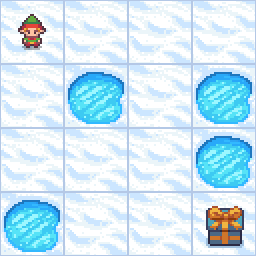

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
